In [1]:
# Cell 1
import pandas as pd

# Fetching the dataset automatically from your newly created GitHub repository
github_raw_url = "https://raw.githubusercontent.com/justnahid01/knn-classification-project/refs/heads/main/student_performance_dataset.csv"

print(f"Fetching dataset automatically from: {github_raw_url}")

# Read the CSV directly from GitHub
df = pd.read_csv(github_raw_url)

print("Dataset loaded successfully without manual intervention!")
print(f"Shape of dataset: {df.shape}")
df.head()

Fetching dataset automatically from: https://raw.githubusercontent.com/justnahid01/knn-classification-project/refs/heads/main/student_performance_dataset.csv
Dataset loaded successfully without manual intervention!
Shape of dataset: (3000, 32)


,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [2]:
# Cell 2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

# 1. Drop useless identifiers (IDs shouldn't be used to calculate distance)
df = df.drop('student_id', axis=1, errors='ignore')

# 2. Handle missing values (Impute median for numerical, mode for categorical)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 3. Encode Target Variable (performance_category)
le_target = LabelEncoder()
y = le_target.fit_transform(df['performance_category'])

# 4. Encode Categorical Features (One-Hot Encoding)
X = df.drop('performance_category', axis=1)
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 5. Split Data (70% Train, 15% Validation, 15% Test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# 6. STANDARDIZATION (Crucial for KNN because it calculates physical distances)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Training set shape: (2099, 38)
Validation set shape: (451, 38)
Test set shape: (450, 38)


Calculating error rates for different K values to generate the Elbow Plot...


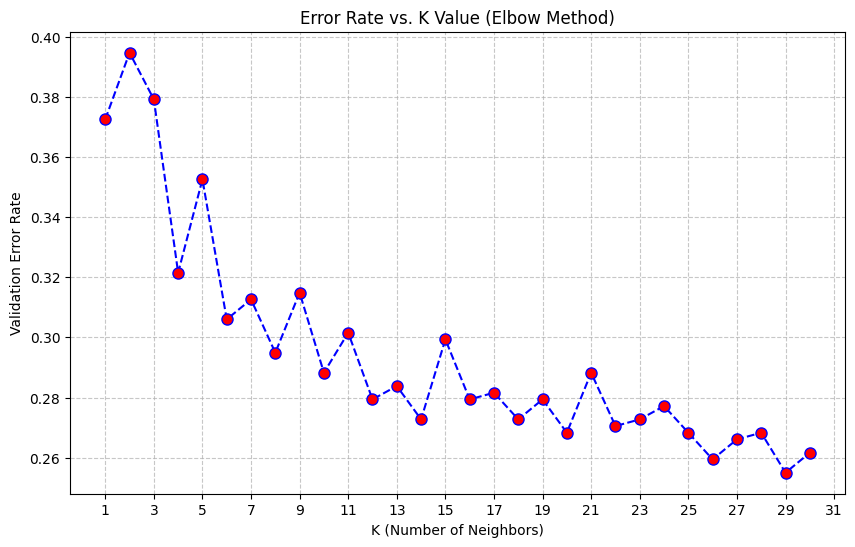

In [3]:
# Cell 3
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

print("Calculating error rates for different K values to generate the Elbow Plot...")

error_rates = []
k_range = range(1, 31) # Testing K values from 1 to 30

# Calculate error rate for each K using the validation set
for k in k_range:
    temp_knn = KNeighborsClassifier(n_neighbors=k)
    temp_knn.fit(X_train_scaled, y_train)
    y_pred_val = temp_knn.predict(X_val_scaled)
    error = np.mean(y_pred_val != y_val)
    error_rates.append(error)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, error_rates, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value (Elbow Method)')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Validation Error Rate')
plt.xticks(np.arange(1, 32, 2))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [5]:
# Cell 4
from sklearn.model_selection import GridSearchCV

# Initialize KNN
knn = KNeighborsClassifier()

# Define Hyperparameters to tune based on assignment requirements
param_grid = {
    'n_neighbors': np.arange(3, 25, 2), # Testing odd K values
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

print("Running Grid Search to find optimal hyperparameters (k, weights, metric)...")
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Save the best model
best_knn = grid_search.best_estimator_

print("\n--- Hyperparameter Tuning Complete ---")
print(f"Optimal K (Neighbors): {grid_search.best_params_['n_neighbors']}")
print(f"Optimal Weights: {grid_search.best_params_['weights']}")
print(f"Optimal Metric: {grid_search.best_params_['metric']}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Running Grid Search to find optimal hyperparameters (k, weights, metric)...

--- Hyperparameter Tuning Complete ---
Optimal K (Neighbors): 23
Optimal Weights: distance
Optimal Metric: manhattan
Best Cross-Validation Accuracy: 0.7756


--- EVALUATION METRICS ON TEST SET ---
              precision    recall  f1-score   support

        High       1.00      0.29      0.45        69
         Low       0.82      0.79      0.80       169
      Medium       0.69      0.86      0.76       212

    accuracy                           0.75       450
   macro avg       0.83      0.65      0.67       450
weighted avg       0.78      0.75      0.73       450



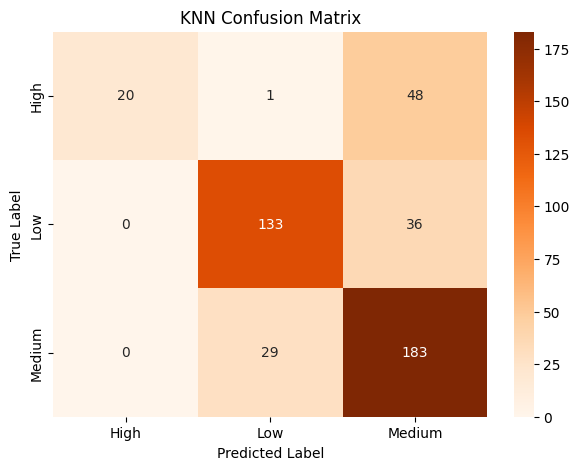

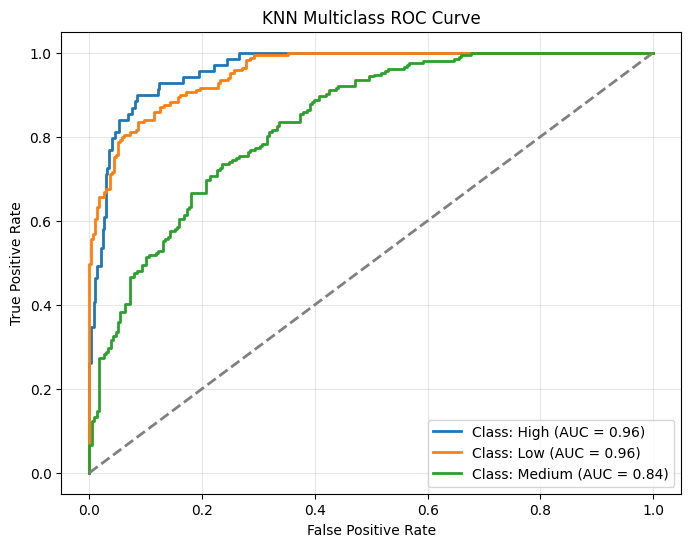

Overall AUC Score: 0.9184


In [6]:
# Cell 5
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Predict on the unseen Test Set
y_pred = best_knn.predict(X_test_scaled)
y_prob = best_knn.predict_proba(X_test_scaled)

# 1. Classification Report
print("--- EVALUATION METRICS ON TEST SET ---")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('KNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. Multiclass ROC/AUC Curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class: {le_target.classes_[i]} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Print Overall AUC
overall_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print(f"Overall AUC Score: {overall_auc:.4f}")

Generating 2D Decision Boundary Plot using PCA to reduce dimensions...


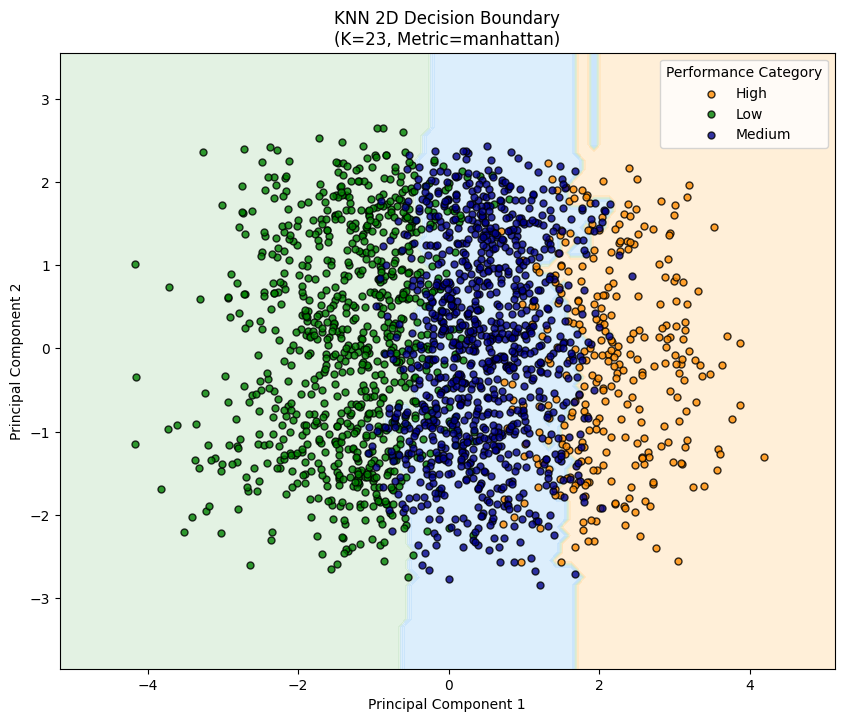

In [7]:
# Cell 6
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

print("Generating 2D Decision Boundary Plot using PCA to reduce dimensions...")

# 1. Reduce dataset to 2 dimensions for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2. Train a new KNN strictly on these 2 dimensions using our optimal parameters
knn_2d = KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors'],
                              weights=grid_search.best_params_['weights'],
                              metric=grid_search.best_params_['metric'])
knn_2d.fit(X_train_pca, y_train)

# 3. Create a mesh grid
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 4. Predict across the grid
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot the boundaries and data points
plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['#FFE0B2', '#C8E6C9', '#BBDEFB'])
cmap_bold = ['darkorange', 'green', 'darkblue']

plt.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_light)

for i, color in zip(range(len(le_target.classes_)), cmap_bold):
    idx = np.where(y_train == i)
    plt.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], c=color,
                label=le_target.classes_[i], edgecolor='k', s=25, alpha=0.8)

plt.title(f"KNN 2D Decision Boundary\n(K={grid_search.best_params_['n_neighbors']}, Metric={grid_search.best_params_['metric']})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Performance Category")
plt.show()